<a href="https://colab.research.google.com/github/RealGoldenGeneral/2537-Assignments/blob/main/cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup (Load Libraries)

In [86]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import random
import os

# Verify if the version is correct
print(f"Tensorflow version: {tf.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# Use GPU if it exists
if tf.config.list_physical_devices("GPU"):
  print(f"\nGPU: {tf.config.list_physical_devices("GPU")[0]}")
else:
  print("GPU not found")

# Set seeds to 42
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Tensorflow version: 2.19.0
Numpy version: 2.0.2
Pandas version: 2.2.2

GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


# Download and Load Dataset
For this mini project, we will use Satellite Image Classification from Kaggle. The dataset has ~5,600 images consisting of cloudy, desert, green area, and water satellite imagery.

In [87]:
# Download dataset from Kaggle
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("mahmoudreda55/satellite-image-classification")
print(f"Dataset downloaded to {path}")

# Print structure
print("\nDataset structure:")
for root, dir, files in os.walk(path):
  level = root.replace(path, "").count(os.sep)
  indent = " " * 4 * (level)
  print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
  for file in files[:2]:
    print(f"{indent}  {file}")

# Find sub directory with 4 subfolders with images
data_dir = None
for root, dir, files in os.walk(path):
  dir[:] = [d for d in dir if len(os.listdir(os.path.join(root, d))) > 0]
  if len(dir) == 4:
    data_dir = root
    break

print(f"\nData directory: {data_dir}")
for d in sorted(os.listdir(data_dir)):
  sub = os.path.join(data_dir, d)
  if os.path.isdir(sub):
    n = len([f for f in os.listdir(sub) if f.lower().endswith(('.png', '.jpeg', '.jpg'))])
    print(f"{d}: {n} images")

Using Colab cache for faster access to the 'satellite-image-classification' dataset.
Dataset downloaded to /kaggle/input/satellite-image-classification

Dataset structure:
satellite-image-classification/  (0 files)
    data/  (0 files)
        cloudy/  (1500 files)
          train_17406.jpg
          train_28684.jpg
        desert/  (1131 files)
          desert(14).jpg
          desert(217).jpg
        green_area/  (1500 files)
          Forest_2838.jpg
          Forest_205.jpg
        water/  (1500 files)
          SeaLake_926.jpg
          SeaLake_907.jpg

Data directory: /kaggle/input/satellite-image-classification/data
cloudy: 1500 images
desert: 1131 images
green_area: 1500 images
water: 1500 images


In [88]:
# Load into Tensorflow
IMG_SIZE = 224
BATCH_SIZE = 32

# Training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.
Class names: ['cloudy', 'desert', 'green_area', 'water']


# Data Exploration

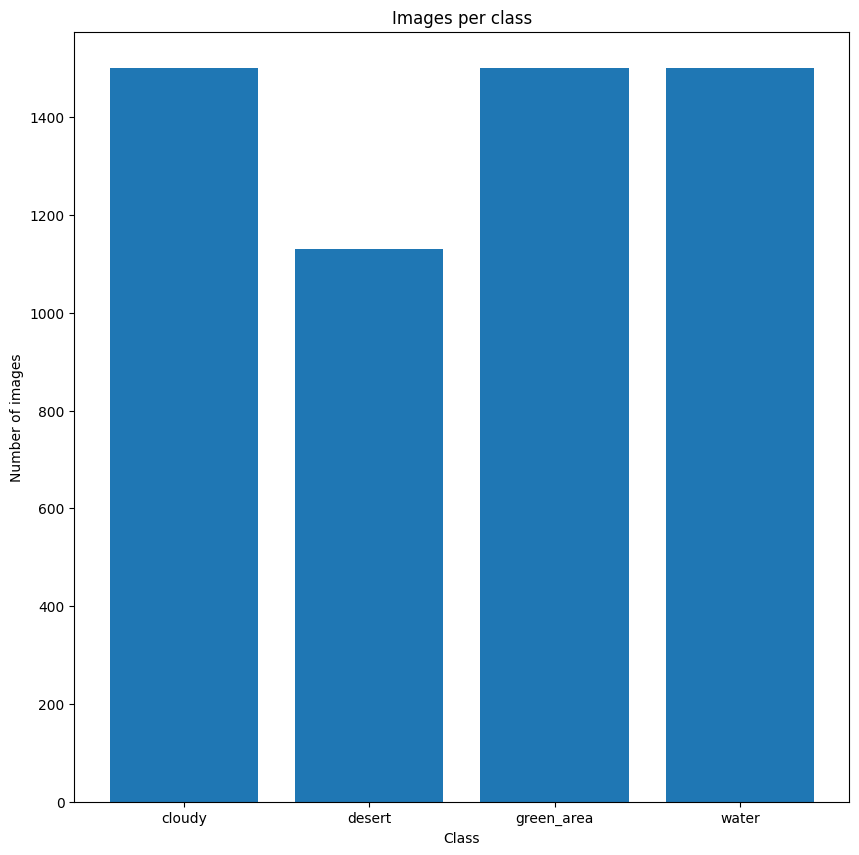

cloudy: 1500 images
desert: 1131 images
green_area: 1500 images
water: 1500 images


In [89]:
# Images per class
plt.figure(figsize=(10, 10))
plt.bar(class_names, [len(os.listdir(os.path.join(data_dir, c))) for c in class_names])
plt.title("Images per class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()

for c in class_names:
  class_dir = os.path.join(data_dir, c)
  images = [os.path.join(class_dir, f) for f in os.listdir(class_dir)]
  print(f"{c}: {len(images)} images")

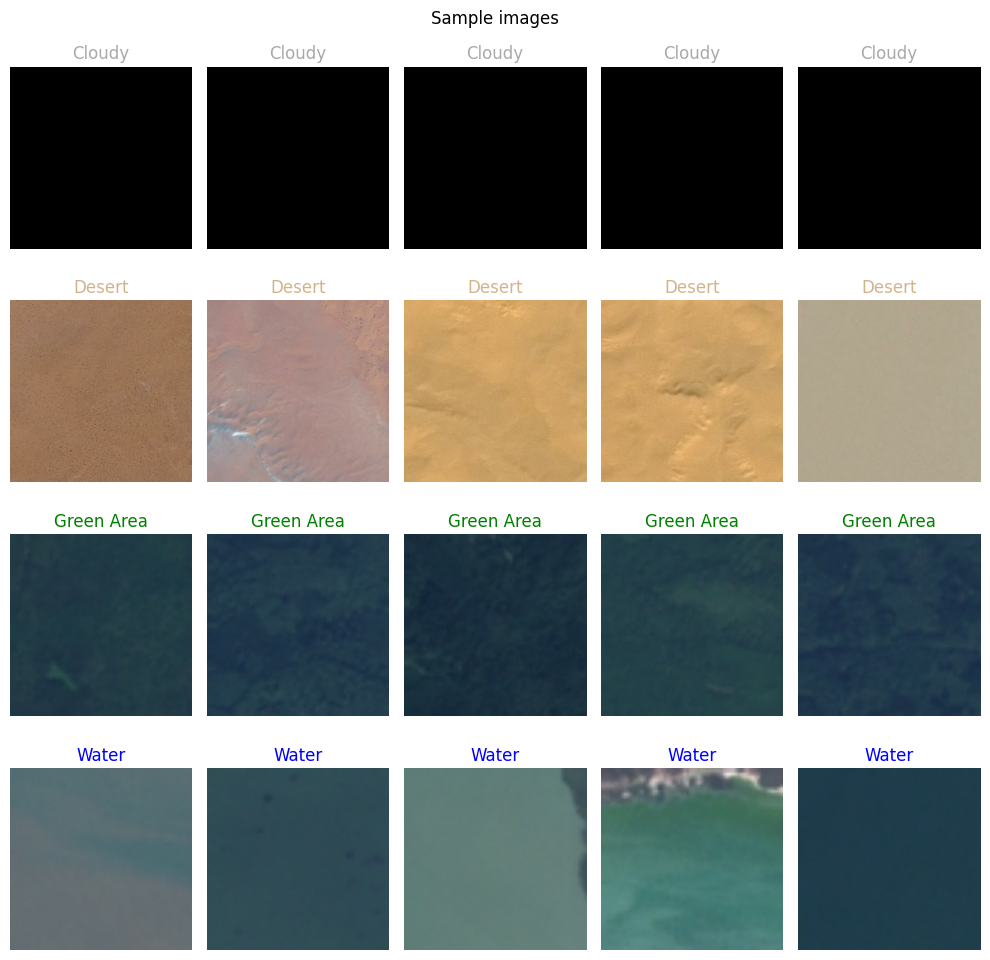

In [96]:
# Visualize sample images
plt.figure(figsize=(10, 10))

cloudy_class = class_names.index('cloudy') if 'cloudy' in class_names else 0
desert_class = class_names.index('desert') if 'desert' in class_names else 0
green_class = class_names.index('green_area') if 'green_area' in class_names else 0
water_class = class_names.index('water') if 'water' in class_names else 0

for images, labels in train_ds.take(1):
  cloudy_mask = labels[:, cloudy_class] == 1
  desert_mask = labels[:, desert_class] == 1
  green_mask = labels[:, green_class] == 1
  water_mask = labels[:, water_class] == 1

  # Show cloudy images
  cloudy_images = images[cloudy_mask]
  for i in range(min(5, len(cloudy_images))):
    ax = plt.subplot(4, 5, i + 1)
    plt.imshow(cloudy_images[i].numpy().astype('uint8'))
    plt.title("Cloudy", color='darkgray')
    plt.axis('off')

  # Show desert images
  desert_images = images[desert_mask]
  for i in range(min(5, len(desert_images))):
    ax = plt.subplot(4, 5, i + 6)
    plt.imshow(desert_images[i].numpy().astype('uint8'))
    plt.title("Desert", color='tan')
    plt.axis('off')

  # Show green area images
  green_images = images[green_mask]
  for i in range(min(5, len(green_images))):
    ax = plt.subplot(4, 5, i + 11)
    plt.imshow(green_images[i].numpy().astype('uint8'))
    plt.title("Green Area", color='green')
    plt.axis('off')

  # Show water images
  water_images = images[water_mask]
  for i in range(min(5, len(water_images))):
    ax = plt.subplot(4, 5, i + 16)
    plt.imshow(water_images[i].numpy().astype('uint8'))
    plt.title("Water", color='blue')
    plt.axis('off')

plt.suptitle("Sample images")
plt.tight_layout()
plt.show()




In [99]:
# Image properties
for images, labels in train_ds.take(1):
  print(f"Batch shape: {images.shape}")
  print(f"Label shape: {labels.shape}")
  print(f"Pixel range: {np.min(images), np.max(images)}")
  print(f"Single image shape: {images[0].shape}")
  print(f"Height: {images[0].shape[0]}")
  print(f"Width: {images[0].shape[1]}")
  print(f"Channels: {images[0].shape[2]}")

Batch shape: (32, 224, 224, 3)
Label shape: (32, 4)
Pixel range: (np.float32(0.0), np.float32(255.0))
Single image shape: (224, 224, 3)
Height: 224
Width: 224
Channels: 3
